In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import subprocess
import os

# 1: Enter file path

In [2]:
file_path = r"E:\Desktop\Timestamping\Timepix data files\Data\Same Intensity\0.5s_1f\raw\0.5s_1f_1.csv"
# file_path = "E:\\Desktop\\Timepix\\Data with He Ni\\data_with_qiskit_idk.csv"

# 2: .tpx3 to .csv

In [ ]:
def process_raw_folder(raw_folder_path: str):
    if not os.path.isdir(raw_folder_path):
        raise ValueError(f"Directory does not exist: {raw_folder_path}")

    # Call the C++ executable
    result = subprocess.run(
        ["./tpx3_to_csv", raw_folder_path],
        capture_output=True,
        text=True
    )
    
    if result.returncode != 0:
        raise RuntimeError(f"C++ conversion failed: {result.stderr}")
    
    print(result.stdout)

    
raw_path = "E:\\Desktop\\Timestamping\\tpx"
process_raw_folder(raw_path)

OSError: [WinError 193] %1 is not a valid Win32 application

# 3: Filter Data

In [3]:
csv_path = file_path.replace('.tpx3', '.csv')
data_main = pd.read_csv(csv_path)
data_main = data_main.dropna(subset=['GlobalTime'])
data_main

,GlobalTime,ToA,SPIDR,FToA,ToT,x,y
0,0.001218,398825.0,819200.0,15,125.0,83,184
1,0.001218,398825.0,819200.0,15,50.0,78,176
2,0.001218,399100.0,819200.0,14,25.0,73,176
3,0.001219,399575.0,819200.0,13,150.0,82,182
4,0.001219,399550.0,819200.0,2,125.0,78,173
...,...,...,...,...,...,...,...
11818871,0.500039,326500.0,499712000.0,5,150.0,51,77
11818872,0.500036,323500.0,499712000.0,6,25.0,53,69
11818873,0.500032,319775.0,499712000.0,2,50.0,62,76
11818874,0.500002,289800.0,499712000.0,6,150.0,84,179


i. Unwrap Global Time

In [ ]:
# def unwrap_toa_inplace(data: pd.DataFrame, toa_col: str) -> None:
#     reset_value=26.8435456
#     add_value = 0
#     toa_original = data[toa_col].values.copy()  # numpy array for speed
#     toa = data[toa_col].values.copy()

#     for i in range(1, len(toa)):
#         if (toa_original[i] < toa_original[i - 1]) and (abs(toa_original[i]-reset_value)<=1):
#             add_value += reset_value
#         toa[i] += add_value
    
#     data["ToA_corrected"] = toa

# unwrap_toa_inplace(data_main, "GlobalTime")
# data_main

,GlobalTime,ToA,ToT,x,y,ToA_corrected
0,0.001218,398825.0,125.0,83,184,0.001218
1,0.001218,398825.0,50.0,78,176,0.001218
2,0.001218,399100.0,25.0,73,176,0.001218
3,0.001219,399575.0,150.0,82,182,0.001219
4,0.001219,399550.0,125.0,78,173,0.001219
...,...,...,...,...,...,...
7128178,0.302084,208350.0,25.0,80,193,0.302084
7128179,0.302028,152450.0,25.0,68,76,0.302028
7128180,0.302075,199625.0,150.0,88,170,0.302075
7128181,0.302065,189850.0,75.0,86,177,0.302065


In [4]:
data_57_72 = data_main[(data_main['x']==83) & (data_main['y']==184)]


In [5]:
data_57_72

,GlobalTime,ToA,SPIDR,FToA,ToT,x,y
0,0.001218,398825.0,819200.0,15,125.0,83,184
83,0.001220,400575.0,819200.0,1,25.0,83,184
352,0.001225,405900.0,819200.0,9,250.0,83,184
1399,0.001234,5300.0,1228800.0,11,175.0,83,184
2347,0.001298,69500.0,1228800.0,10,25.0,83,184
...,...,...,...,...,...,...,...
11813036,0.499759,47350.0,499712000.0,0,200.0,83,184
11814011,0.499784,71525.0,499712000.0,2,75.0,83,184
11815178,0.499854,141575.0,499712000.0,2,50.0,83,184
11816200,0.499911,198650.0,499712000.0,4,125.0,83,184


In [12]:
data_57_72.to_csv(r"E:\Desktop\Timestamping\Timepix data files\Data\Same Intensity\0.5s_1f\raw\data_57_72.csv", index=False)

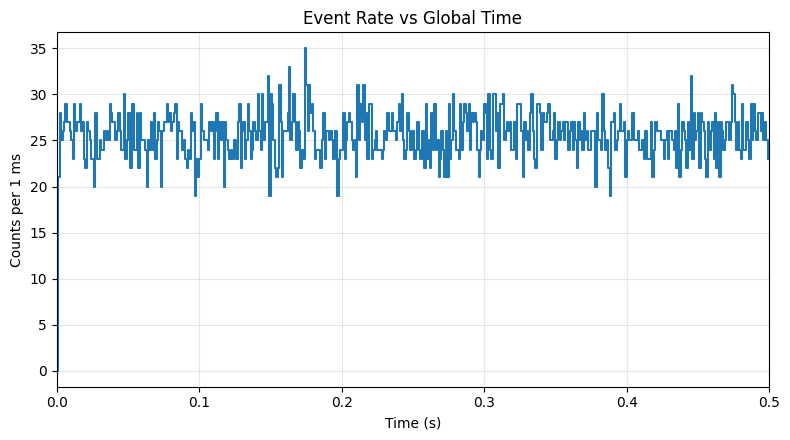

In [6]:
gt = data_57_72['GlobalTime'].to_numpy()

# ----- choose physically meaningful bin width -----
bin_width = 1e-3   # 1 ms bins (change if needed)
bins = np.arange(0, 0.5 + bin_width, bin_width)

counts, edges = np.histogram(gt, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

plt.figure(figsize=(8, 4.5))
plt.step(centers, counts, where='mid')
plt.xlabel("Time (s)")
plt.ylabel("Counts per 1 ms")
plt.title("Event Rate vs Global Time")
plt.xlim(0, 0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
hist_data = pd.DataFrame({
    "bin_start_s": edges[:-1],
    "bin_end_s": edges[1:],
    "bin_center_s": centers,
    "counts": counts
})

hist_data

,bin_start_s,bin_end_s,bin_center_s,counts
0,0.000,0.001,0.0005,0
1,0.001,0.002,0.0015,21
2,0.002,0.003,0.0025,28
3,0.003,0.004,0.0035,25
4,0.004,0.005,0.0045,26
...,...,...,...,...
495,0.495,0.496,0.4955,28
496,0.496,0.497,0.4965,25
497,0.497,0.498,0.4975,27
498,0.498,0.499,0.4985,25


In [8]:
hist_data.to_csv(r"E:\Desktop\Timestamping\Timepix data files\Data\Same Intensity\0.5s_1f\raw\global_time_histogram.csv", index=False)

In [ ]:
gt = data_57_72["GlobalTime"].to_numpy()
tot = data_57_72["ToT"].to_numpy()

# ----- binning -----
bin_width = 0.01   # 10 ms bins → matches your visual density
bins = np.arange(0, 0.5 + bin_width, bin_width)

# digitize timestamps into bins
bin_index = np.digitize(gt, bins) - 1

# compute stats per bin
bin_start = bins[:-1]
bin_end = bins[1:]
bin_center = 0.5 * (bin_start + bin_end)

avg_tot = []
counts = []

for i in range(len(bin_start)):
    mask = bin_index == i
    counts.append(np.sum(mask))
    avg_tot.append(np.mean(tot[mask]) if np.any(mask) else np.nan)

avg_tot = np.array(avg_tot)
counts = np.array(counts)

# ----- store data -----
lifetime_data = pd.DataFrame({
    "bin_start_s": bin_start,
    "bin_end_s": bin_end,
    "bin_center_s": bin_center,
    "avg_ToT": avg_tot,
    "counts": counts
})

lifetime_data.to_csv(r"E:\Desktop\Timestamping\Timepix data files\Data\Same Intensity\0.5s_1f\raw\lifetime_pixel_57_72.csv", index=False)
print("Saved → lifetime_pixel_57_72.csv")


Saved → lifetime_pixel_57_72.csv


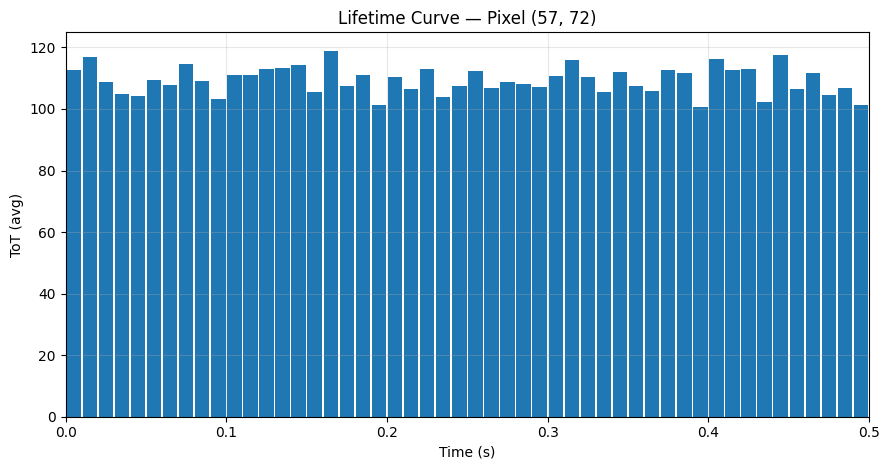

In [12]:
plt.figure(figsize=(9, 4.8))
plt.bar(bin_center, avg_tot, width=bin_width*0.9)
plt.xlabel("Time (s)")
plt.ylabel("ToT (avg)")
plt.title("Lifetime Curve — Pixel (57, 72)")
plt.xlim(0, 0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ii. Visualize

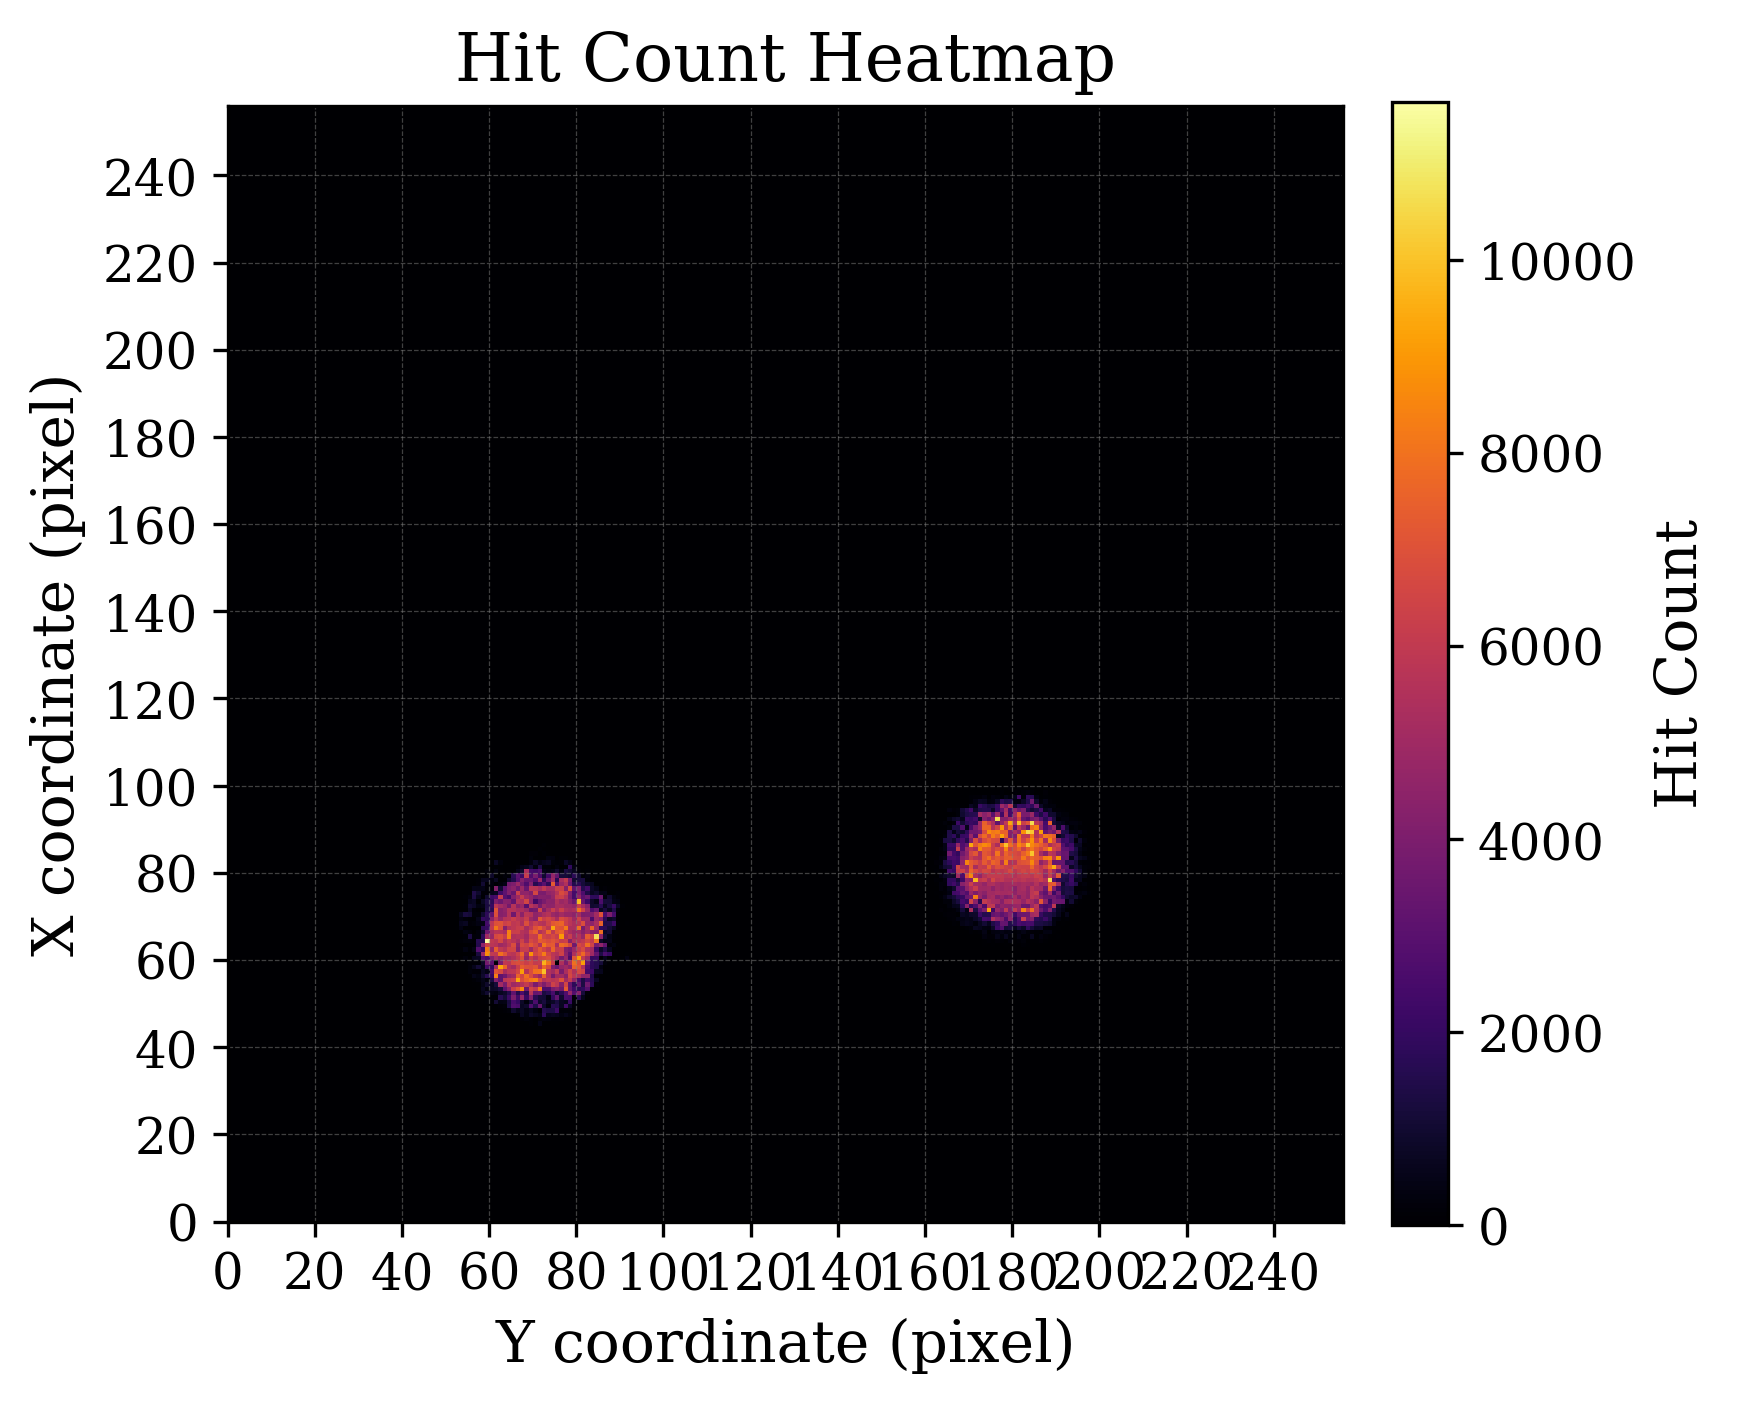

In [11]:
# Optional filter on ToT
data = data_main.copy()

# Group by (x, y) and count entries
agg_data = data.groupby(['x', 'y']).size().reset_index(name='Count')
# agg_data = agg_data[agg_data["Count"]<1000]

# Full 256x256 pixel grid
x_full = np.arange(0, 256)
y_full = np.arange(0, 256)
full_grid = pd.MultiIndex.from_product([x_full, y_full], names=['x', 'y']).to_frame(index=False)

# Merge and fill missing counts with 0
full_data = pd.merge(full_grid, agg_data, on=['x', 'y'], how='left')
full_data['Count'] = full_data['Count'].fillna(0)

# Pivot for heatmap
heatmap_data = full_data.pivot(index='x', columns='y', values='Count')

# --- Plotting ---
plt.rcParams.update({
    "font.size": 14,
    "font.family": "serif",   # For professional look; use 'sans-serif' if journal prefers
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300
})

fig, ax = plt.subplots(figsize=(6, 5.5))  # Use size appropriate for 1-column journal layout

# Heatmap
cax = ax.imshow(
    heatmap_data.values,
    cmap='inferno',
    origin='lower',
    vmin=0,
    vmax=full_data['Count'].max(),
    extent=[0, 256, 0, 256],
    interpolation='none'
)

# Colorbar
cbar = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Hit Count', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Labels
ax.set_xlabel('Y coordinate (pixel)')
ax.set_ylabel('X coordinate (pixel)')
ax.set_title('Hit Count Heatmap')

# Grid settings
ax.set_xticks(np.arange(0, 257, 20))
ax.set_yticks(np.arange(0, 257, 20))
ax.grid(which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.5)

# Minor grid for clarity if needed
# ax.set_xticks(np.arange(0.5, 256.5, 1), minor=True)
# ax.set_yticks(np.arange(0.5, 256.5, 1), minor=True)
# ax.grid(which='minor', linestyle='-', linewidth=0.2, color='gray', alpha=0.3)

# Tight and square layout
ax.set_aspect('equal')
plt.tight_layout()

# Save figure (optional)
# plt.savefig("hit_count_heatmap.png", dpi=600, bbox_inches='tight')

plt.show()


iii. Manually add X and Y coordinates for both clusters

In [14]:
data1 = data_main[(data_main["x"] < 90) & (data_main["x"] > 40) & (data_main["y"] < 100) & (data_main["y"] > 50)]
data2 = data_main[(data_main["x"] < 100) & (data_main["x"] > 60) & (data_main["y"] < 200) & (data_main["y"] > 160)]
data_processed = pd.concat([data1, data2], ignore_index=True)
# data_processed = data1.copy()

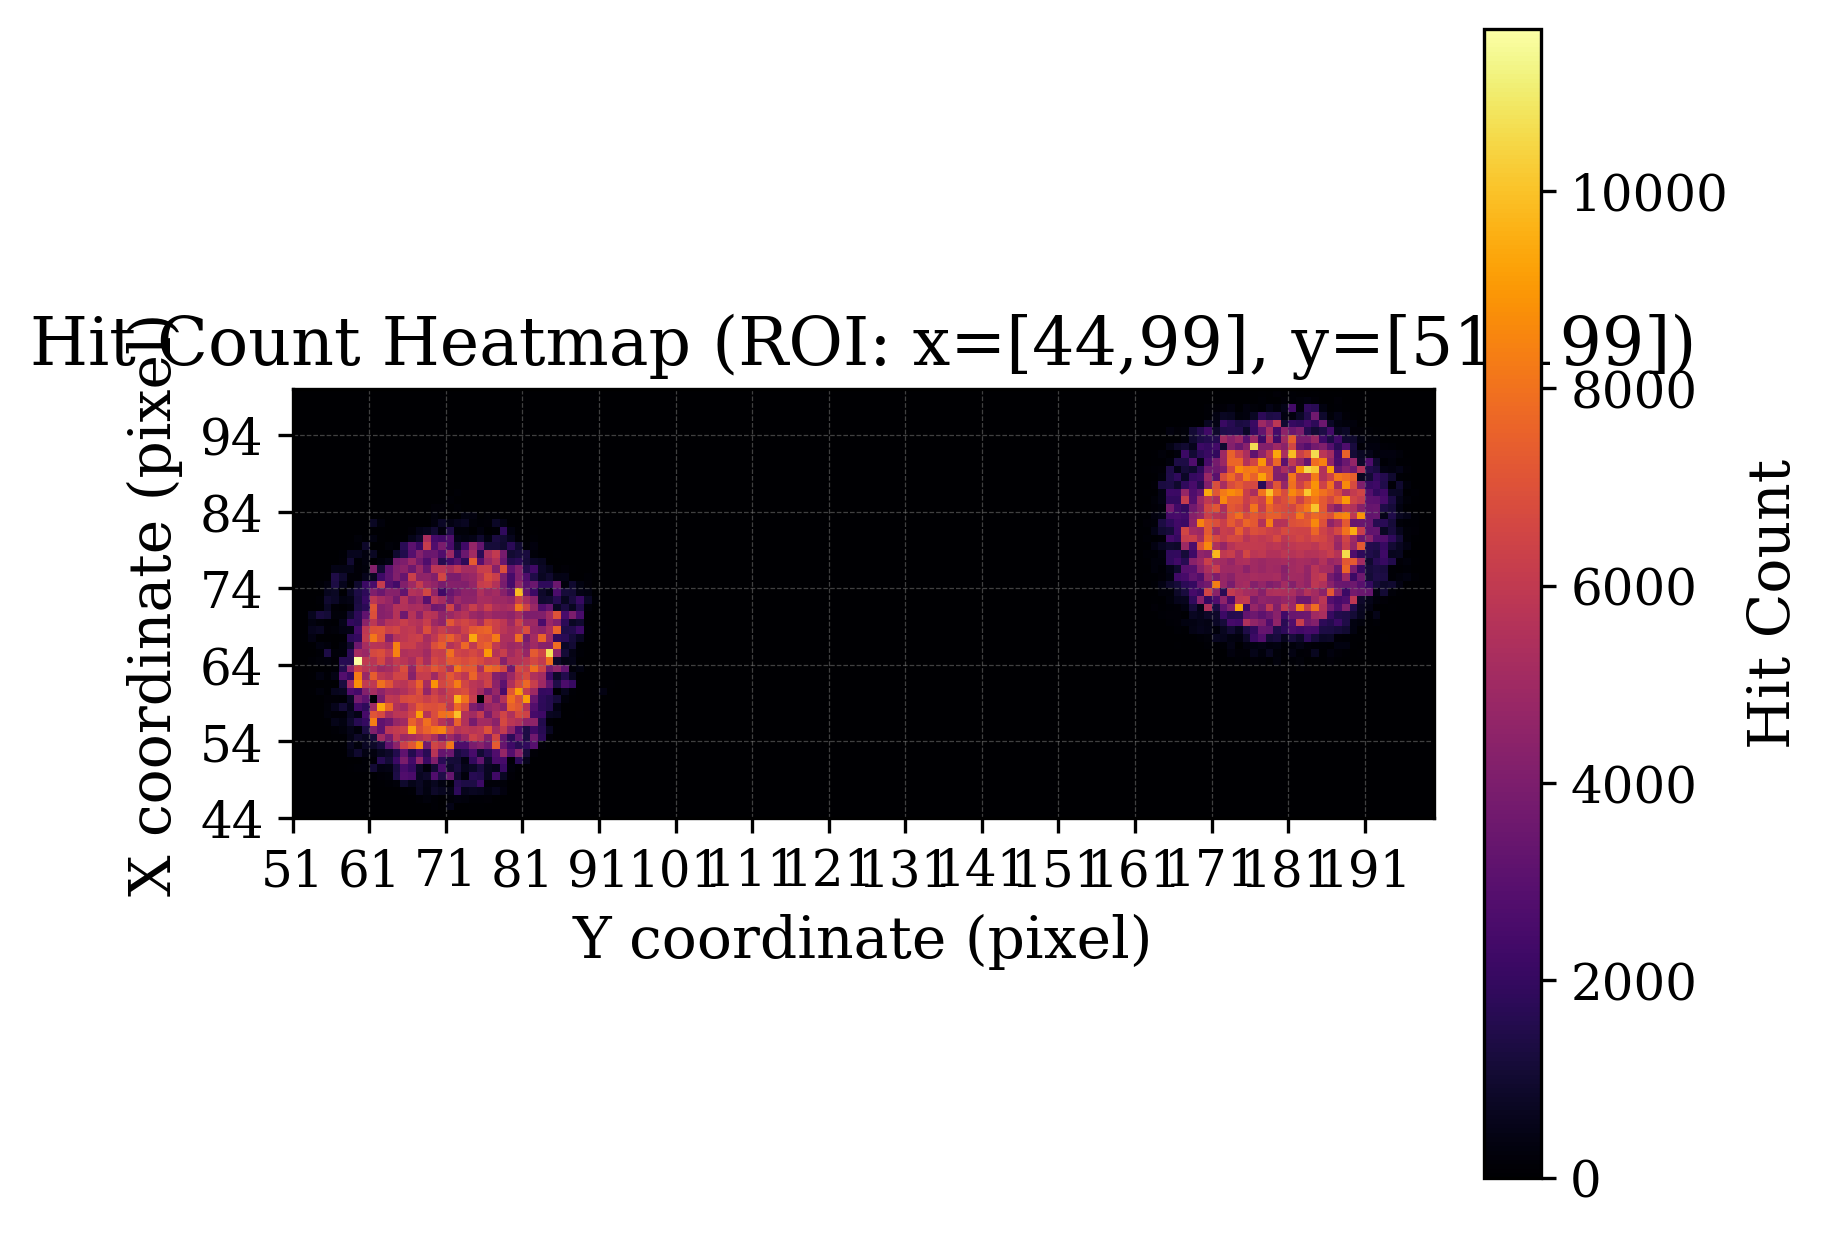

In [15]:
agg_data = data_processed.groupby(['x', 'y']).size().reset_index(name='Count')

# Create full grid for this smaller region
x_min, x_max = agg_data['x'].min(), agg_data['x'].max()
y_min, y_max = agg_data['y'].min(), agg_data['y'].max()
x_full = np.arange(x_min, x_max + 1)
y_full = np.arange(y_min, y_max + 1)
full_grid = pd.MultiIndex.from_product([x_full, y_full], names=['x', 'y']).to_frame(index=False)

# Merge and fill missing pixels with 0
full_data = pd.merge(full_grid, agg_data, on=['x', 'y'], how='left')
full_data['Count'] = full_data['Count'].fillna(0)

# Pivot for heatmap
heatmap_data = full_data.pivot(index='x', columns='y', values='Count')

# --- Plotting ---
plt.rcParams.update({
    "font.size": 14,
    "font.family": "serif",
    "figure.dpi": 300
})

fig, ax = plt.subplots(figsize=(6, 5.5))

cax = ax.imshow(
    heatmap_data.values,
    cmap='inferno',
    origin='lower',
    vmin=0,
    vmax=full_data['Count'].max(),
    extent=[y_min, y_max + 1, x_min, x_max + 1],
    interpolation='none'
)

# Colorbar
cbar = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Hit Count', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Labels
ax.set_xlabel('Y coordinate (pixel)')
ax.set_ylabel('X coordinate (pixel)')
ax.set_title(f'Hit Count Heatmap (ROI: x=[{x_min},{x_max}], y=[{y_min},{y_max}])')

# Grid settings
ax.set_xticks(np.arange(y_min, y_max + 1, 10))
ax.set_yticks(np.arange(x_min, x_max + 1, 10))
ax.grid(which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.5)

ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [49]:
# df must have columns: ToA, x, y

df = data_main.sort_values("GlobalTime").reset_index(drop=True)

# -------- SAME PIXEL --------
g = df.groupby(["x", "y"])["GlobalTime"]
same_dt = g.diff()                                # Δt within each pixel
same_pixel_min_dt = same_dt.min()                 # global minimum

same_idx = same_dt.idxmin()                       # row where min occurs
same_row_curr = df.loc[same_idx]
same_row_prev = df.loc[same_idx - 1]              # previous hit of same pixel

# -------- DIFFERENT PIXEL --------
dt = df["GlobalTime"].diff()
pixel_changed = (df["x"].diff() != 0) | (df["y"].diff() != 0)
diff_dt = dt[pixel_changed]

diff_pixel_min_dt = diff_dt.min()                 # global minimum
diff_idx = diff_dt.idxmin()                       # row where min occurs
diff_row_curr = df.loc[diff_idx]
diff_row_prev = df.loc[diff_idx - 1]              # previous hit (different pixel)

# -------- PRINT RESULTS --------
print("Min Δt (same pixel):", same_pixel_min_dt)
print("  pixel:", (same_row_curr["x"], same_row_curr["y"]))
print("  prev idx/ToA:", same_idx - 1, same_row_prev["GlobalTime"])
print("  curr idx/ToA:", same_idx,     same_row_curr["GlobalTime"])

print("\nMin Δt (different pixels):", diff_pixel_min_dt)
print("  prev pixel:", (diff_row_prev["x"], diff_row_prev["y"]))
print("  curr pixel:", (diff_row_curr["x"], diff_row_curr["y"]))
print("  prev idx/ToA:", diff_idx - 1, diff_row_prev["GlobalTime"])
print("  curr idx/ToA:", diff_idx,     diff_row_curr["GlobalTime"])


Min Δt (same pixel): 4.609374999742233e-07
  pixel: (76.0, 72.0)
  prev idx/ToA: 5730374 0.243085575
  curr idx/ToA: 5730375 0.24308558125

Min Δt (different pixels): 0.0
  prev pixel: (83.0, 184.0)
  curr pixel: (83.0, 172.0)
  prev idx/ToA: 0 0.001218025
  curr idx/ToA: 1 0.001218025


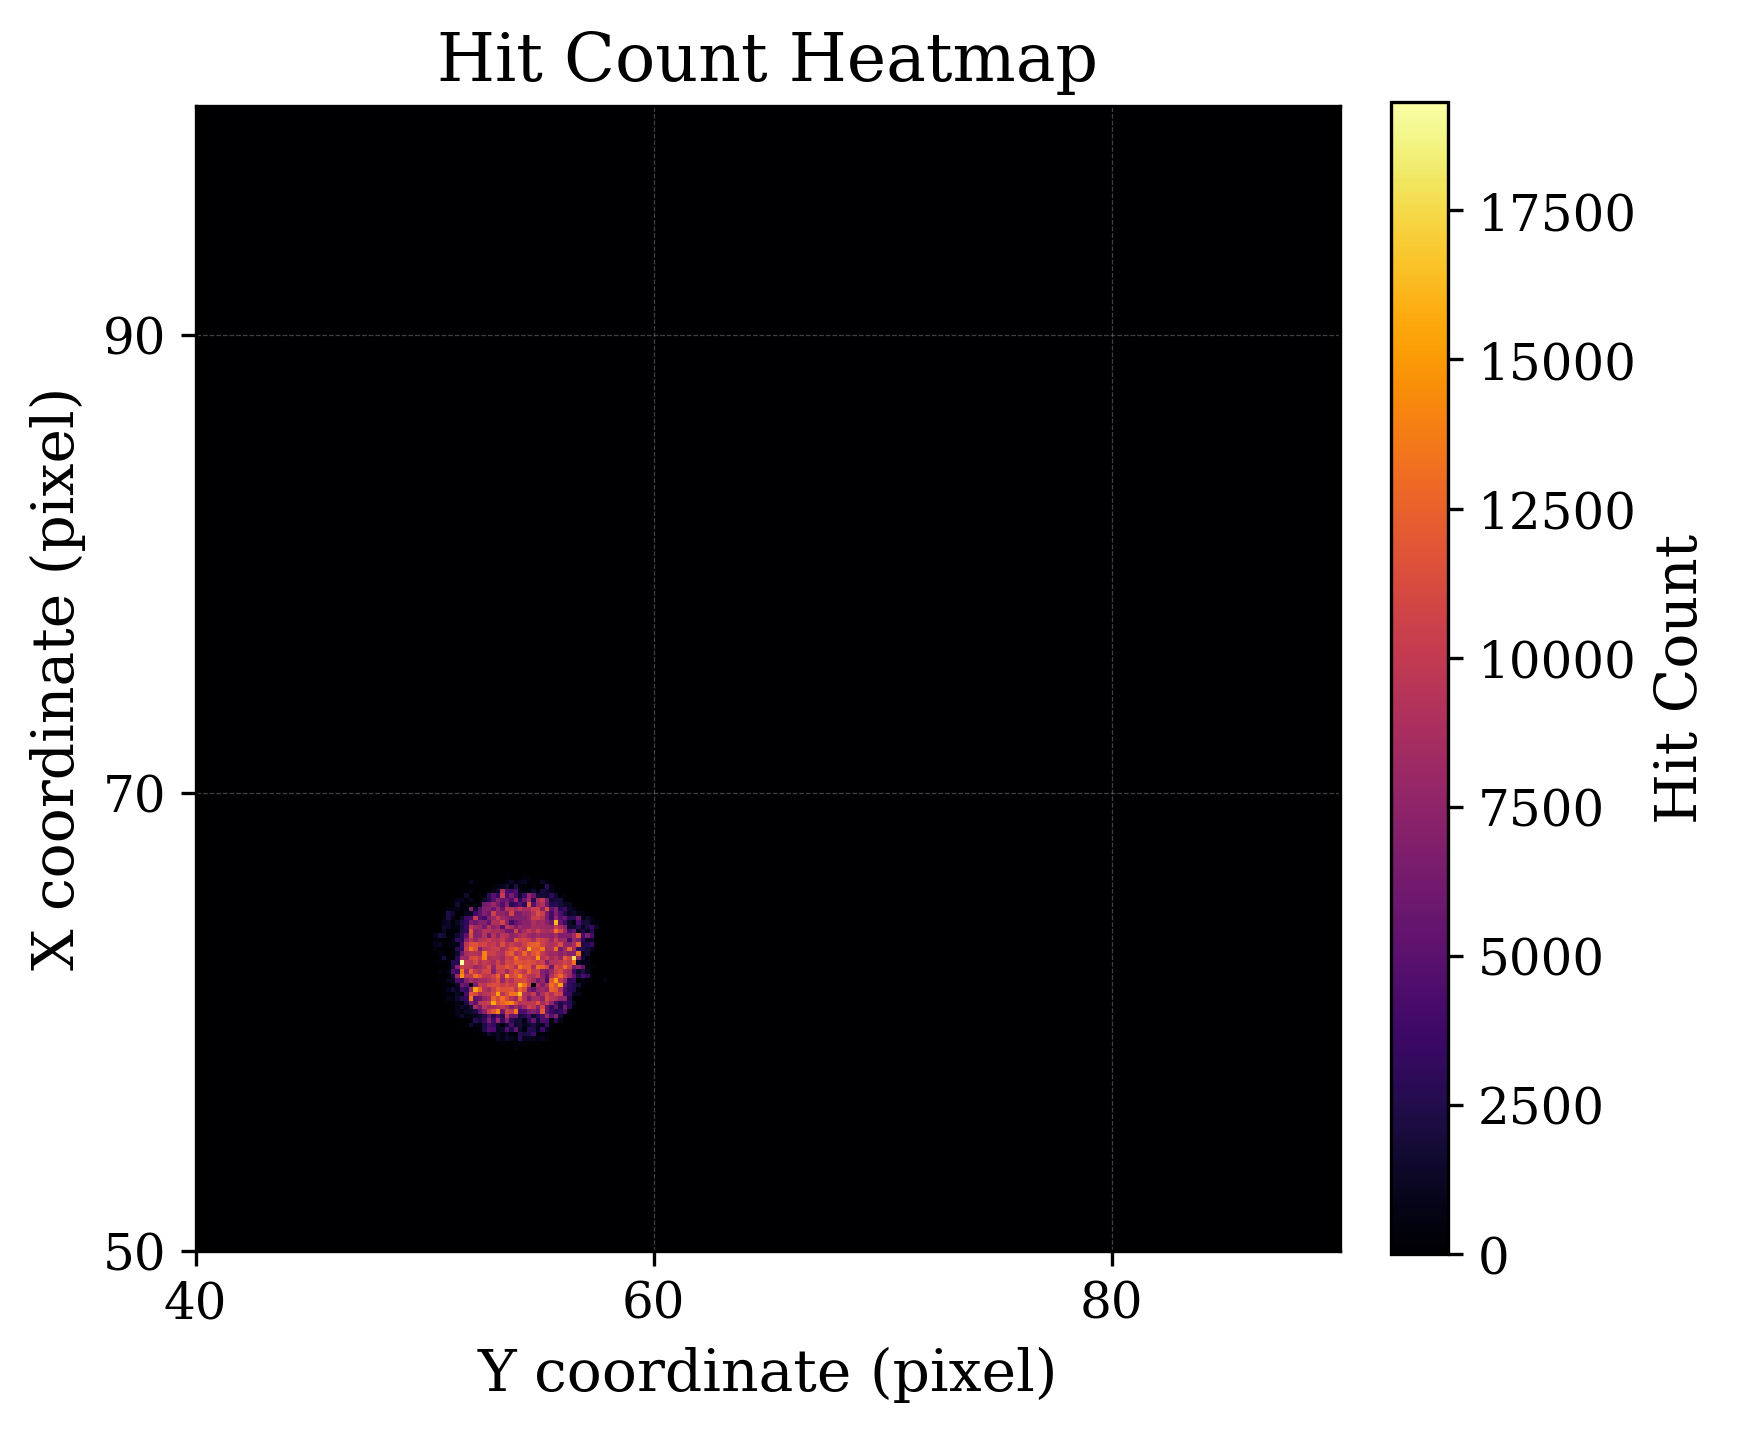

In [ ]:
# Optional filter on ToT
data = data_processed.copy()

# Group by (x, y) and count entries
agg_data = data.groupby(['x', 'y']).size().reset_index(name='Count')

# Full 256x256 pixel grid
x_full = np.arange(0, 256)
y_full = np.arange(0, 256)
full_grid = pd.MultiIndex.from_product([x_full, y_full], names=['x', 'y']).to_frame(index=False)

# Merge and fill missing counts with 0
full_data = pd.merge(full_grid, agg_data, on=['x', 'y'], how='left')
full_data['Count'] = full_data['Count'].fillna(0)

# Pivot for heatmap
heatmap_data = full_data.pivot(index='x', columns='y', values='Count')

# --- Plotting ---
plt.rcParams.update({
    "font.size": 14,
    "font.family": "serif",   # For professional look; use 'sans-serif' if journal prefers
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300
})

fig, ax = plt.subplots(figsize=(6, 5.5))  # Use size appropriate for 1-column journal layout

# Heatmap
cax = ax.imshow(
    heatmap_data.values,
    cmap='inferno',
    origin='lower',
    vmin=0,
    vmax=full_data['Count'].max(),
    extent=[0, 256, 0, 256],
    interpolation='none'
)

# Colorbar
cbar = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Hit Count', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Labels
ax.set_xlabel('Y coordinate (pixel)')
ax.set_ylabel('X coordinate (pixel)')
ax.set_title('Hit Count Heatmap')

# Grid settings
ax.set_xticks(np.arange(0, 257, 20))
ax.set_yticks(np.arange(0, 257, 20))
ax.grid(which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.5)

# Minor grid for clarity if needed
# ax.set_xticks(np.arange(0.5, 256.5, 1), minor=True)
# ax.set_yticks(np.arange(0.5, 256.5, 1), minor=True)
# ax.grid(which='minor', linestyle='-', linewidth=0.2, color='gray', alpha=0.3)

# Tight and square layout
ax.set_aspect('equal')
plt.tight_layout()

# Save figure (optional)
# plt.savefig("hit_count_heatmap.png", dpi=600, bbox_inches='tight')

plt.show()


iv. Save processed data

In [ ]:
data_processed.to_csv("D:\\Desktop\\Timepix\\Data with He Ni\\Measurement_apr_19_2025_17h01m31s\\raw\\processed_data.csv")

In [ ]:
data_main[(data_main["ToA"]<) and (data_main["ToA"]>)].to_csv("E:\\Desktop\\Timepix\\Data with He Ni\\trial.csv")

# 4: Visualize Data Parameters

i. Number of datapoints in each cluster

In [16]:
print("Number of datapoints in ch1: ", len(data1))
print("Number of datapoints in ch2: ", len(data2))

Number of datapoints in ch1:  3718313
Number of datapoints in ch2:  3409354


In [17]:
(len(data1)-len(data2))/len(data1)

0.08309117602525662

In [18]:
def get_distribution(data: pd.DataFrame, x: int, y: int, steps=0.1):
    data_main = data[(data["x"] == x) & (data["y"] == y)]

    if data_main.empty:
        return None, None  # Return None if no data for the given (X, Y)

    t_max = round(data_main["ToA_corrected"].max())

    counts = []
    time_interval = np.arange(steps, t_max + steps, steps)

    j = 0
    for i in time_interval:
        data_new = data_main[(data_main["ToA_corrected"] > j) & (data_main["ToA_corrected"] < i)]
        counts.append(data_new.shape[0])
        j = i

    # Plot the distribution
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(time_interval, counts, width=steps, align='edge', edgecolor='black')
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Counts per interval")
    ax.set_title("Time-Binned Histogram of ToA_corrected Events")
    ax.grid(True)
    fig.tight_layout()
    ax.grid()

    return fig, ax

def find_1to1_matching(c1_df, c2_df, tolerance=0.05):
    """
    Find one-to-one matches between (X, Y) pixels from cluster 0 and cluster 1 
    such that their counts are within a given tolerance and no repeats occur.
    
    Parameters:
    - c1_df, c2_df: DataFrames with columns ['X', 'Y', 'count']
    - tolerance: allowable relative difference

    Returns:
    - matched_pairs: DataFrame with matched (X_c1, Y_c1, count_c1) <-> (X_c2, Y_c2, count_c2)
    """
    # Make mutable copies
    c2_remaining = c2_df.copy()
    used_c2_indices = set()
    matches = []

    for idx1, row1 in c1_df.iterrows():
        count1 = row1['count']
        best_match = None
        best_diff = float('inf')
        best_idx2 = None

        for idx2, row2 in c2_remaining.iterrows():
            if idx2 in used_c2_indices:
                continue
            count2 = row2['count']
            rel_diff = abs(count1 - count2) / max(count1, count2)

            if rel_diff <= tolerance and rel_diff < best_diff:
                best_diff = rel_diff
                best_match = row2
                best_idx2 = idx2

        if best_match is not None:
            matches.append({
                'X_c1': row1['x'], 'Y_c1': row1['y'], 'count_c1': count1,
                'X_c2': best_match['x'], 'Y_c2': best_match['y'], 'count_c2': best_match['count'],
                'rel_diff': best_diff
            })
            used_c2_indices.add(best_idx2)

    return pd.DataFrame(matches).sort_values('rel_diff')

def c12_correspondence(grouped_df_c1, grouped_df_c2, tolerance=0.05):
    grouped_df_c1 = (
        grouped_df_c1.groupby(["x", "y"])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )
    grouped_df_c2 = (
        grouped_df_c2.groupby(["x", "y"])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )

    matched = find_1to1_matching(grouped_df_c1, grouped_df_c2, tolerance)

    return matched


ii. Time Distribution of a pixel

In [ ]:
x = 81
y = 61

fig, ax = get_distribution(data_processed, x, y, 0.5)
fig.show()

iii. Correspondence between 2 clusters

In [ ]:
matched  = c12_correspondence(data1, data2, np.inf)
matched

In [ ]:
x1 = 77
y1 = 60

matched_data = matched[(matched["X_c1"]==x1) & (matched["Y_c1"]==y1)]
x2 = int(matched_data["X_c2"])
y2 = int(matched_data["Y_c2"])

fig1, ax1 = get_distribution(data_processed, x1, y1, 0.5)
fig1.show()

fig2, ax2 = get_distribution(data_processed, x2, y2, 0.5)
fig2.show()

In [ ]:
x2 = 77
y2 = 60

matched_data = matched[(matched["X_c2"]==x2) & (matched["Y_c2"]==y2)]
x1 = int(matched_data["X_c1"])
y1 = int(matched_data["Y_c1"])

fig1, ax1 = get_distribution(data_processed, x1, y1, 0.5)
fig1.show()

fig2, ax2 = get_distribution(data_processed, x2, y2, 0.5)
fig2.show()

# 5. G2T

In [25]:
# Convert to NumPy arrays
# toa1 = data1["ToA"].to_numpy()
# toa2 = data2["ToA"].to_numpy()

toa1 = data1["GlobalTime"].to_numpy()
toa2 = data2["GlobalTime"].to_numpy()


# toa1 = data_main["Chnl1"].to_numpy()
# toa2 = data_main["Chnl2"].to_numpy()

In [26]:
toa1

array([0.00124996, 0.00125022, 0.00125182, ..., 0.30203871, 0.30202342,
       0.30202766])

In [27]:
toa1 = toa1[~np.isnan(toa1)]
toa2 = toa2[~np.isnan(toa2)]

In [ ]:
# def filter_min_gap(toa, min_gap=1e-5):
#     result = [toa[0]]
#     last = toa[0]
    
#     for t in toa[1:]:
#         if t - last >= min_gap:
#             result.append(t)
#             last = t
#     return np.array(result)

In [ ]:
# toa1_new = filter_min_gap(toa1)
# toa2_new = filter_min_gap(toa2)

In [32]:
data_final = pd.DataFrame({
    'chn1': toa1[:len(toa2)],
    'chn2': toa2
})
data_final

,chn1,chn2
0,0.001250,0.001218
1,0.001250,0.001218
2,0.001252,0.001218
3,0.001252,0.001219
4,0.001251,0.001219
...,...,...
3409349,0.277053,0.302081
3409350,0.277056,0.302084
3409351,0.277056,0.302075
3409352,0.277063,0.302065


In [31]:
data_final = data_final[:5000]

In [28]:
data_final.to_csv("E:\\Desktop\\Timepix\\Data with He Ni\\same_intensity_timepix\\1s_1f_1_processed_same_gap_10um_tpx.csv", index=False)

In [33]:
just_less = -50e-6
just_greater = 50e-6
dt = 1e-6

In [ ]:
# x = np.arange(just_less, just_greater, dt)

# counts = [0]*len(x)
# corrector = -1*(just_less//dt)

# for ToA1 in toa1:
#     for ToA2 in toa2:
#         Tau = ToA2 - ToA1
#         if Tau>=just_less and Tau<=just_greater:
#             idx = int(np.floor((Tau - just_less)/dt))
#             counts[idx] += 1

# counts

In [ ]:
x = np.arange(just_less, just_greater, dt)
counts = np.zeros(len(x), dtype=int)

for t1 in toa1:
    taus = toa2 - t1

    # Filter taus within the range
    mask = (taus >= just_less) & (taus < just_greater)
    valid_taus = taus[mask]

    # Compute bin indices for valid taus
    bin_indices = ((valid_taus - just_less) // dt).astype(int)
    bin_indices = np.clip(bin_indices, 0, len(x) - 1)  # Prevent out-of-bounds
    counts += np.bincount(bin_indices, minlength=len(x))
    
counts

KeyboardInterrupt: 

In [50]:
denominator = ((sum(counts/1000)/len(counts))*1000).astype(int)
denominator

np.int64(9922)

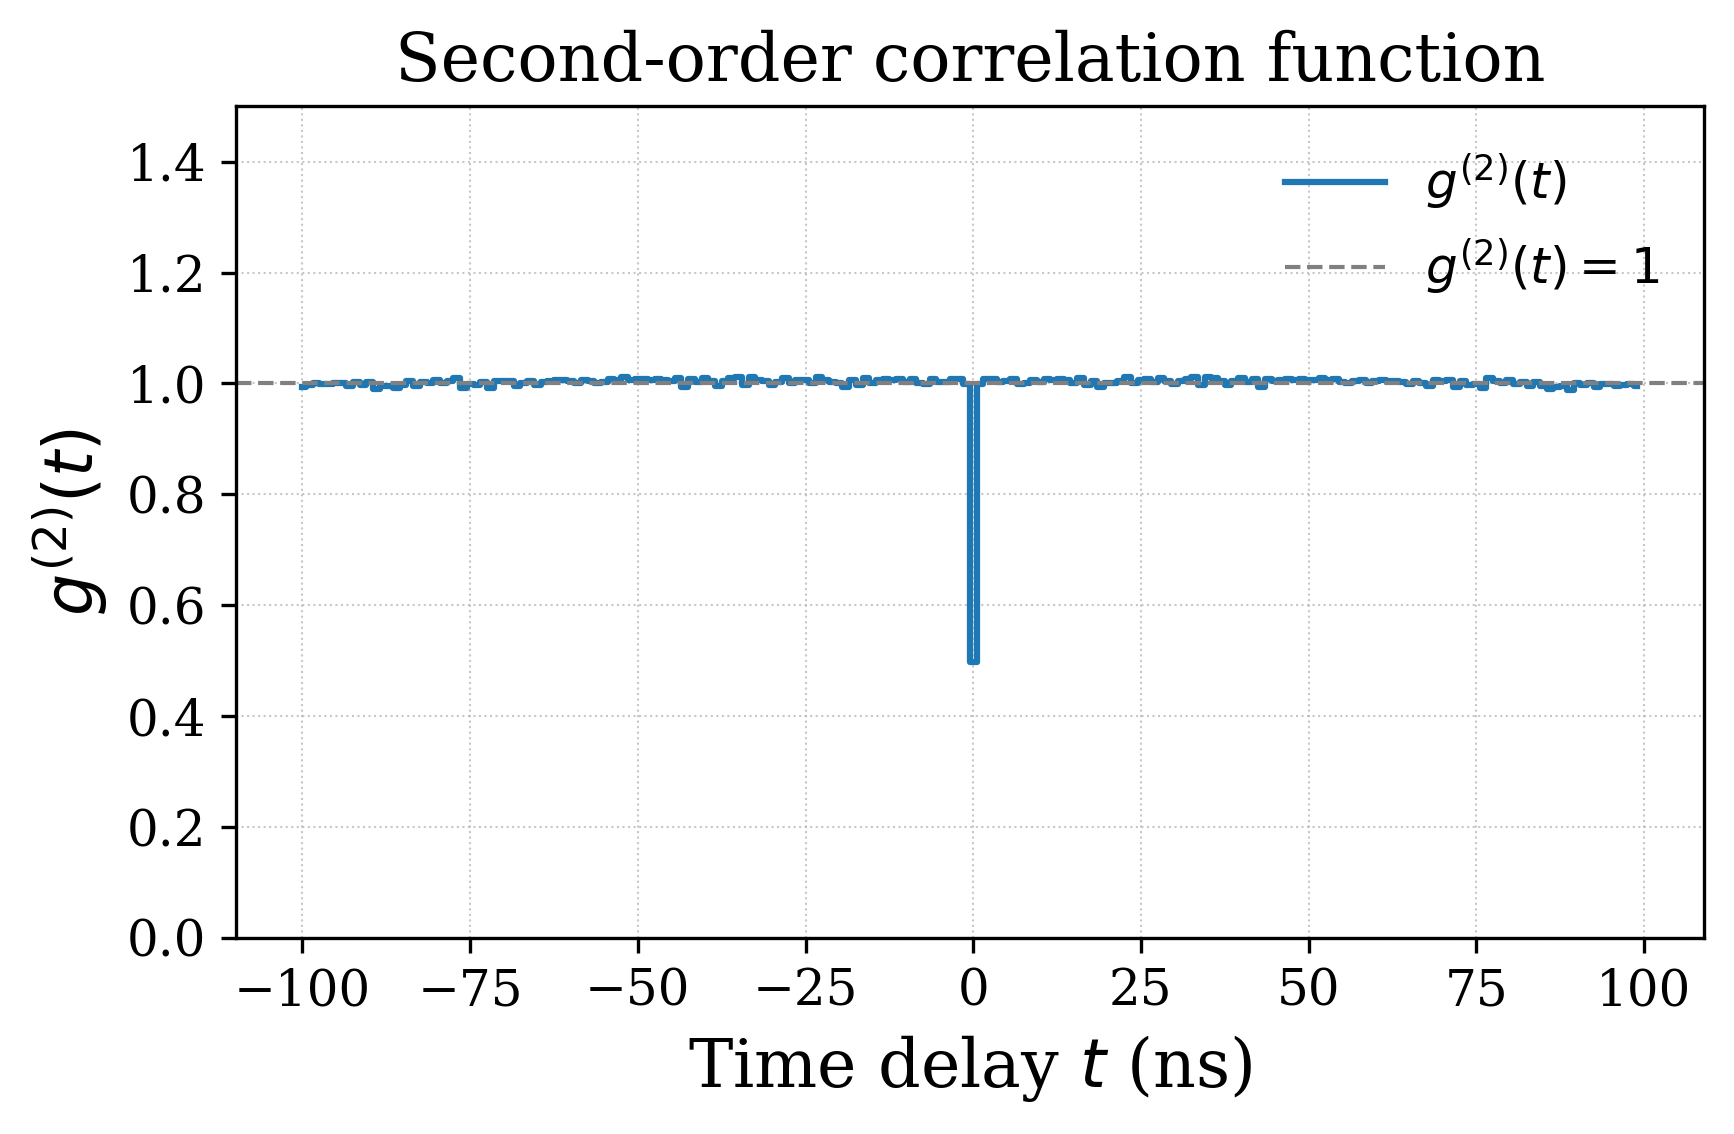

In [51]:
# Example: g2 = counts / denominator, x = time delays (in ns assumed)
# x, g2 already defined
g2 = np.array(counts)/ denominator
# g2 = np.where((g2 >= 0.75) & (g2 <= 1.25), g2, 1)

# Plot settings for paper
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 300
})

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))  # Size fits single-column journal

# Plot g2 with step style
ax.plot(x, g2, drawstyle='steps-mid', color='tab:blue', linewidth=1.5, label=r"$g^{(2)}(t)$")

# Horizontal line at g²=1 (uncorrelated photons)
ax.axhline(1, color='gray', linestyle='--', linewidth=1, label=r"$g^{(2)}(t) = 1$")

# Axis labels and title
ax.set_xlabel(r"Time delay $t$ (ns)")
ax.set_ylabel(r"$g^{(2)}(t)$")
ax.set_ylim(0, 1.5)
ax.set_title(r"Second-order correlation function")

# Grid and legend
ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.7)
ax.legend(loc='best', frameon=False)

# Tight layout
plt.tight_layout()

# Optional: Save to file (high-res PNG or vector PDF)
# plt.savefig("g2_plot.pdf", format="pdf", bbox_inches="tight")
# plt.savefig("g2_plot.png", dpi=600, bbox_inches="tight")

plt.show()
